In [1]:
from pathlib import Path

import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from filmoscopie.vision import embed, movie

In [2]:
root = Path("../trailers/support/animation")
points = []
tags = []
for class_ in embed.classes(root):
    assert class_.is_dir(), f"{class_} is not a dir"
    points_batch = []
    videos = list(movie.videos(class_))
    print(len(videos), "videos in", class_.name)
    arrays = list(class_.glob("*.ndarray"))
    not_indexed = []
    for video in tqdm(videos):
        assert video.is_file(), f"{video} is not a file"
        vectors = [v for v in arrays if v.name.startswith(video.name)]
        if len(vectors) == 0:
            not_indexed.append(video)
            continue
        points_batch += [np.fromfile(f) for f in vectors]
    tags += [class_.name] * len(points_batch)
    points += points_batch
assert len(points) != 0
assert len(points) == len(tags)
print(len(not_indexed),not_indexed[:min(5,len(not_indexed))])

247 videos in cartoon


100%|██████████| 247/247 [00:03<00:00, 77.71it/s] 


158 videos in real_humans


100%|██████████| 158/158 [00:01<00:00, 144.58it/s]

77 [PosixPath('../trailers/support/animation/real_humans/Accidents (1989) Official Trailer #1 - Science-Fiction Movie HD [U6F7vjrKRZg].mkv'), PosixPath('../trailers/support/animation/real_humans/2012 (2009) Trailer #1 ｜ Movieclips Classic Trailers [XejECBUbJzo].mkv'), PosixPath('../trailers/support/animation/real_humans/Star Wars： Episode VI - Return of the Jedi (1983) Teaser Trailer #1 ｜ Movieclips Classic Trailers [QbnX33Gorno].mkv'), PosixPath('../trailers/support/animation/real_humans/Crossworlds (1996) Official Trailer #1 - Sci-Fi Movie HD [qm3YWiHUip8].mkv'), PosixPath('../trailers/support/animation/real_humans/OCCUPIED CITY DE STEVE MCQUEEN - BANDE ANNONCE [nOP8s0xVJ9M].mkv')]


In [3]:
points_train, points_test, tags_train, tags_test = train_test_split(
    points, tags, test_size=0.3, random_state=0)
clf = svm.SVC()
clf.fit(points_train, tags_train)
print(f"Confidence: {clf.score(points_test, tags_test) *100:0.2f}%")
clf

Confidence: 70.41%


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [4]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [5]:
root = Path("../trailers/support/animation")
bag = []
for class_ in embed.classes(root, hide="."):
    videos = list(movie.videos(class_))
    arrays = list(class_.glob("*.ndarray"))
    for video in tqdm(videos):
        assert video.is_file(), f"{video} is not a file"
        vectors = [v for v in arrays if v.name.startswith(video.name)]
        if len(vectors) == 0:
            continue
        bag += [np.fromfile(f) for f in vectors]
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(bag)
kmeans

100%|██████████| 5/5 [00:00<00:00, 14.12it/s]


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


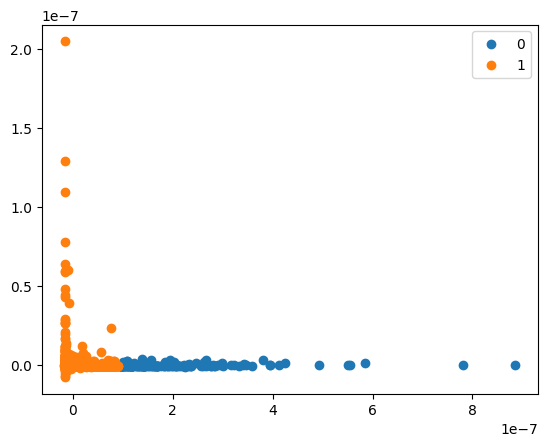

In [6]:
pca = PCA(2)

df = pca.fit_transform(bag)
label = kmeans.fit_predict(df)
 
u_labels = np.unique(label)
 
#plotting the results:
 
for i in u_labels:
    plt.scatter(df[label == i , 0] , df[label == i , 1] , label = i)
plt.legend()
plt.show()